In [19]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import wandb
import argparse

from pathlib import Path

try:
    BASE_PATH = str(Path(__file__).resolve().parent.parent.parent)
except NameError:
    # __file__이 정의되지 않은 경우 (Jupyter 환경)
    BASE_PATH = str(Path.cwd().parent.parent.parent)

print("BASE_PATH:", BASE_PATH)

import sys
sys.path.append(BASE_PATH)

from _03_homeworks.homework_2.titanic_dataset import get_preprocessed_dataset


# -------------------------
# Data
# -------------------------
def get_data(return_test: bool = False):
    train_ds, valid_ds, test_ds = get_preprocessed_dataset()

    # 학습 로더: 셔플 O / 검증 로더: 셔플 X
    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=wandb.config.batch_size,
        shuffle=True,
        pin_memory=torch.cuda.is_available()
    )
    valid_loader = DataLoader(
        dataset=valid_ds,
        batch_size=len(valid_ds),
        shuffle=False,
        pin_memory=torch.cuda.is_available()
    )

    if return_test:
        test_loader = DataLoader(
            dataset=test_ds,
            batch_size=len(test_ds),
            shuffle=False,
            pin_memory=torch.cuda.is_available()
        )
        return train_loader, valid_loader, test_loader

    return train_loader, valid_loader


# -------------------------
# Model
# -------------------------
class MyModel(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_input, wandb.config.n_hidden_unit_list[0]),
            nn.ReLU(),
            nn.Linear(wandb.config.n_hidden_unit_list[0], wandb.config.n_hidden_unit_list[1]),
            nn.ReLU(),
            nn.Linear(wandb.config.n_hidden_unit_list[1], n_output),
        )

    def forward(self, x):
        return self.model(x)


def get_model_and_optimizer(device):
    model = MyModel(n_input=10, n_output=2).to(device)
    optimizer = optim.SGD(model.parameters(), lr=wandb.config.learning_rate)
    return model, optimizer


# -------------------------
# Train Loop
# -------------------------
def training_loop(model, optimizer, train_loader, valid_loader, device):
    n_epochs = wandb.config.epochs
    loss_fn = nn.CrossEntropyLoss()
    next_print_epoch = 100

    for epoch in range(1, n_epochs + 1):
        # ---- Train ----
        model.train()
        train_loss_sum, train_batches = 0.0, 0
        for batch in train_loader:
            x = batch["input"].to(device)
            y = batch["target"].to(device)

            logits = model(x)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_batches += 1

        train_loss = train_loss_sum / max(train_batches, 1)

        # ---- Valid ----
        model.eval()
        valid_loss_sum, valid_batches = 0.0, 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch["input"].to(device)
                y = batch["target"].to(device)
                logits = model(x)
                loss = loss_fn(logits, y)
                valid_loss_sum += loss.item()
                valid_batches += 1

        valid_loss = valid_loss_sum / max(valid_batches, 1)

        # ---- Log ----
        wandb.log({
            "Epoch": epoch,
            "Training loss": train_loss,
            "Validation loss": valid_loss
        })

        if epoch >= next_print_epoch:
            print(f"Epoch {epoch}, Training loss {train_loss:.4f}, Validation loss {valid_loss:.4f}")
            next_print_epoch += 100


# -------------------------
# Main
# -------------------------
def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    current_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')
    config = {
        "epochs": args.epochs,
        "batch_size": args.batch_size,
        "learning_rate": 1e-3,
        "n_hidden_unit_list": [20, 20],
    }

    wandb.init(
        mode="online" if args.wandb else "disabled",
        project="my_model_training",
        notes="My first wandb experiment",
        tags=["my_model", "titanic"],
        name=current_time_str,
        config=config
    )

    train_loader, valid_loader = get_data()
    model, optimizer = get_model_and_optimizer(device)

    # (선택) 파라미터/그래디언트 추적
    # wandb.watch(model, log="all", log_freq=100)

    training_loop(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
        device=device
    )
    wandb.finish()


# -------------------------
# argparse
# -------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--wandb", action=argparse.BooleanOptionalAction, default=False, help="True or False")
    parser.add_argument("-b", "--batch_size", type=int, default=512, help="Batch size (int, default: 512)")
    parser.add_argument("-e", "--epochs", type=int, default=1_000, help="Number of training epochs (int, default: 1_000)")
    # ... (parser.add_argument 들 위는 그대로)


    # ... (parser.add_argument 들 위는 그대로)

    args, _ = parser.parse_known_args()   # <- unknown args 무시
    main(args)



BASE_PATH: c:\Users\mj
Using device: cpu
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  \
0       0.0       3    1  22.0      1      0   7.2500         2      2   
1       1.0       1    0  38.0      1      0  71.2833         0      3   
2       1.0       3    0  26.0      0      0   7.9250         2      1   
3       1.0       1    0  35.0      1      0  53.1000         2      3   
4       0.0       3    1  35.0      0      0   8.0500         2      2   
5       0.0       3    1  29.0      0      0   8.4583         1      2   
6       0.0       1    1  54.0      0      0  51.8625         2      2   
7       0.0       3    1   2.0      3      1  21.0750         2      0   
8       1.0       3    0  27.0      0      2  11.1333         2      3   
9       1.0       2    0  14.0      1      0  30.0708         0      3   

 

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6061, Validation loss 0.5736
Epoch 200, Training loss 0.5821, Validation loss 0.5572
Epoch 300, Training loss 0.5910, Validation loss 0.5484
Epoch 400, Training loss 0.5956, Validation loss 0.5418
Epoch 500, Training loss 0.5897, Validation loss 0.5389
Epoch 600, Training loss 0.5693, Validation loss 0.5375
Epoch 700, Training loss 0.5716, Validation loss 0.5357
Epoch 800, Training loss 0.5781, Validation loss 0.5341
Epoch 900, Training loss 0.5855, Validation loss 0.5328
Epoch 1000, Training loss 0.5833, Validation loss 0.5293


In [12]:
#요구사항 2-1 : 활성화 함수 비교 실험 코드 
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import wandb
import argparse

try:
    BASE_PATH = str(Path(__file__).resolve().parent.parent.parent)
except NameError:
    BASE_PATH = str(Path.cwd().resolve().parent)

print("BASE_PATH:", BASE_PATH)

import sys
sys.path.append(BASE_PATH)

from _03_homeworks.homework_2.titanic_dataset import get_preprocessed_dataset


# data 
def get_data(return_test=False):
    train_ds, valid_ds, test_ds = get_preprocessed_dataset()

    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=wandb.config.batch_size,
        shuffle=True
    )
    valid_loader = DataLoader(
        dataset=valid_ds,
        batch_size=len(valid_ds)
    )

    if return_test:
        test_loader = DataLoader(
            dataset=test_ds,
            batch_size=len(test_ds)
        )
        return train_loader, valid_loader, test_loader

    return train_loader, valid_loader


def get_activation(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "elu":
        return nn.ELU()
    if name == "leakyrelu":
        return nn.LeakyReLU(0.01) 
    raise ValueError(f"Unknown activation: {name}")


# model
class MyModel(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        act = get_activation(wandb.config.activation)

        self.model = nn.Sequential(
            nn.Linear(n_input, wandb.config.n_hidden_unit_list[0]),
            act,  
            nn.Linear(wandb.config.n_hidden_unit_list[0], wandb.config.n_hidden_unit_list[1]),
            act,
            nn.Linear(wandb.config.n_hidden_unit_list[1], n_output),
        )

    def forward(self, x):
        x = self.model(x)
        return x


def get_model_and_optimizer(device):
    my_model = MyModel(n_input=10, n_output=2).to(device)
    optimizer = optim.SGD(my_model.parameters(), lr=wandb.config.learning_rate)
    return my_model, optimizer


@torch.no_grad()
def _accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        x = batch["input"].to(device)
        y = batch["target"].to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


def training_loop(model, optimizer, train_data_loader, validation_data_loader, device):
    n_epochs = wandb.config.epochs
    loss_fn = nn.CrossEntropyLoss()
    next_print_epoch = 100

    best_val_loss = float("inf")
    best_epoch = -1
    best_val_acc = 0.0

    for epoch in range(1, n_epochs + 1):
        # train 
        loss_train = 0.0
        model.train()
        num_trains = 0
        for batch in train_data_loader:
            x = batch["input"].to(device)
            y = batch["target"].to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            loss_train += loss.item()
            num_trains += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validation 
        model.eval()
        loss_validation = 0.0
        num_validations = 0
        with torch.no_grad():
            for batch in validation_data_loader:
                x = batch["input"].to(device)
                y = batch["target"].to(device)
                logits = model(x)
                loss = loss_fn(logits, y)
                loss_validation += loss.item()
                num_validations += 1

        train_loss = loss_train / num_trains
        val_loss = loss_validation / num_validations
        val_acc = _accuracy(model, validation_data_loader, device)

        # logging
        wandb.log({
            "Epoch": epoch,
            "Training loss": train_loss,
            "Validation loss": val_loss,
            "Validation acc": val_acc,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch

        if epoch >= next_print_epoch:
            print(
                f"Epoch {epoch}, "
                f"Training loss {train_loss:.4f}, "
                f"Validation loss {val_loss:.4f}, "
                f"Val acc {val_acc:.4f}"
            )
            next_print_epoch += 100

    # run 요약 반환
    return {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
    }


def run_one_activation(device, args, activation_name):
    """활성화 함수 1개로 1회 학습 실행하고 요약 리턴"""
    current_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    config = {
        'epochs': args.epochs,
        'batch_size': args.batch_size,
        'learning_rate': 1e-3,
        'n_hidden_unit_list': [20, 20],
        'activation': activation_name,
    }

    wandb.init(
        mode="online" if args.wandb else "disabled",
        project="my_model_training",
        notes="Activation comparison",
        tags=["my_model", "titanic", "activation_sweep"],
        name=f"{current_time_str}_{activation_name}",
        config=config
    )

    train_loader, valid_loader = get_data()
    model, optimizer = get_model_and_optimizer(device)
    summary = training_loop(model, optimizer, train_loader, valid_loader, device)
    wandb.finish()

    return {
        "activation": activation_name,
        **summary
    }


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device;", device)

    # 4개 활성화 함수 비교 실행
    activations = ["sigmoid", "relu", "elu", "leakyrelu"]
    results = []
    for act in activations:
        print(f"\n=== Activation: {act} ===")
        res = run_one_activation(device, args, act)
        results.append(res)
        print(f"[Summary] best@epoch={res['best_epoch']}  "
              f"val_loss={res['best_val_loss']:.4f}  "
              f"val_acc={res['best_val_acc']:.4f}")

    # 콘솔 표 요약
    print("\n===== Activation Comparison (sorted by best_val_loss) =====")
    results_sorted = sorted(results, key=lambda r: r["best_val_loss"])
    header = f"{'Activation':<12} {'BestEpoch':>9} {'BestValLoss':>12} {'BestValAcc':>11}"
    print(header)
    print("-" * len(header))
    for r in results_sorted:
        print(f"{r['activation']:<12} {r['best_epoch']:>9d} {r['best_val_loss']:>12.4f} {r['best_val_acc']:>11.4f}")


# https://docs.wandb.ai/guides/track/config
if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    parser.add_argument("--wandb", action=argparse.BooleanOptionalAction, default=False)
    parser.add_argument("-b", "--batch_size", type=int, default=512)
    parser.add_argument("-e", "--epochs", type=int, default=1_000)
    parser.add_argument("--activation", type=str, default="relu",
                        choices=["relu", "sigmoid", "elu", "leakyrelu"],
                        help="(단일 실행용) Activation function for hidden layers")

    import sys
    if "ipykernel" in sys.modules:
        args = parser.parse_args([])         
    else:
        args = parser.parse_args()

    main(args)


BASE_PATH: C:\Users\mj\git\link_dl
Using device; cpu

=== Activation: sigmoid ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  \
0       0.0       3    1  22.0      1      0   7.2500         2      2   
1       1.0       1    0  38.0      1      0  71.2833         0      3   
2       1.0       3    0  26.0      0      0   7.9250         2      1   
3       1.0       1    0  35.0      1      0  53.1000         2      3   
4       0.0       3    1  35.0      0      0   8.0500         2      2   
5       0.0       3    1  29.0      0      0   8.4583         1      2   
6       0.0       1    1  54.0      0      0  51.8625         2      2   
7       0.0       3    1   2.0      3      1  21.0750         2      0   
8       1.0       3    0  27.0      0      2  11.1333         2      3   
9       1.0       2    0  14.0     

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6742, Validation loss 0.6670, Val acc 0.6573
Epoch 200, Training loss 0.6677, Validation loss 0.6548, Val acc 0.6573
Epoch 300, Training loss 0.6709, Validation loss 0.6493, Val acc 0.6573
Epoch 400, Training loss 0.6648, Validation loss 0.6464, Val acc 0.6573
Epoch 500, Training loss 0.6690, Validation loss 0.6446, Val acc 0.6573
Epoch 600, Training loss 0.6595, Validation loss 0.6432, Val acc 0.6573
Epoch 700, Training loss 0.6681, Validation loss 0.6422, Val acc 0.6573
Epoch 800, Training loss 0.6607, Validation loss 0.6415, Val acc 0.6573
Epoch 900, Training loss 0.6592, Validation loss 0.6407, Val acc 0.6573
Epoch 1000, Training loss 0.6653, Validation loss 0.6402, Val acc 0.6573
[Summary] best@epoch=999  val_loss=0.6402  val_acc=0.6573

=== Activation: relu ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Far

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6215, Validation loss 0.6508, Val acc 0.6348
Epoch 200, Training loss 0.6038, Validation loss 0.6266, Val acc 0.6798
Epoch 300, Training loss 0.5976, Validation loss 0.6220, Val acc 0.6517
Epoch 400, Training loss 0.5999, Validation loss 0.6211, Val acc 0.6573
Epoch 500, Training loss 0.5856, Validation loss 0.6192, Val acc 0.6854
Epoch 600, Training loss 0.5836, Validation loss 0.6171, Val acc 0.6854
Epoch 700, Training loss 0.5862, Validation loss 0.6187, Val acc 0.6629
Epoch 800, Training loss 0.5846, Validation loss 0.6181, Val acc 0.6742
Epoch 900, Training loss 0.5809, Validation loss 0.6178, Val acc 0.6742
Epoch 1000, Training loss 0.5819, Validation loss 0.6168, Val acc 0.6854
[Summary] best@epoch=978  val_loss=0.6161  val_acc=0.6854

=== Activation: elu ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6119, Validation loss 0.6092, Val acc 0.6742
Epoch 200, Training loss 0.5957, Validation loss 0.6033, Val acc 0.7022
Epoch 300, Training loss 0.5915, Validation loss 0.5985, Val acc 0.7079
Epoch 400, Training loss 0.5874, Validation loss 0.5905, Val acc 0.6966
Epoch 500, Training loss 0.5837, Validation loss 0.5882, Val acc 0.7079
Epoch 600, Training loss 0.5908, Validation loss 0.5874, Val acc 0.7303
Epoch 700, Training loss 0.5779, Validation loss 0.5819, Val acc 0.7360
Epoch 800, Training loss 0.5780, Validation loss 0.5787, Val acc 0.7360
Epoch 900, Training loss 0.5833, Validation loss 0.5771, Val acc 0.7303
Epoch 1000, Training loss 0.5729, Validation loss 0.5751, Val acc 0.7303
[Summary] best@epoch=981  val_loss=0.5738  val_acc=0.7360

=== Activation: leakyrelu ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch   

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6259, Validation loss 0.6673, Val acc 0.5899
Epoch 200, Training loss 0.6067, Validation loss 0.6629, Val acc 0.6180
Epoch 300, Training loss 0.5883, Validation loss 0.6601, Val acc 0.6236
Epoch 400, Training loss 0.6001, Validation loss 0.6571, Val acc 0.6292
Epoch 500, Training loss 0.5954, Validation loss 0.6556, Val acc 0.6236
Epoch 600, Training loss 0.5944, Validation loss 0.6543, Val acc 0.6236
Epoch 700, Training loss 0.5930, Validation loss 0.6539, Val acc 0.6180
Epoch 800, Training loss 0.6014, Validation loss 0.6535, Val acc 0.6292
Epoch 900, Training loss 0.5972, Validation loss 0.6512, Val acc 0.6236
Epoch 1000, Training loss 0.5843, Validation loss 0.6515, Val acc 0.6236
[Summary] best@epoch=936  val_loss=0.6508  val_acc=0.6236

===== Activation Comparison (sorted by best_val_loss) =====
Activation   BestEpoch  BestValLoss  BestValAcc
-----------------------------------------------
elu                981       0.5738      0.7360
relu            

In [13]:
#BestValAcc가 leakyrelu가 가장 높게 나와서, 최적의 activation function은 Leakyrelu로 선정하고, 아래는 batch size 4가지 테스트 예정입니다.

In [14]:


#요구사항 2-2 : 배치 크기 비교 실험 코드 
try:
    BASE_PATH = str(Path(__file__).resolve().parent.parent.parent)
except NameError:
    BASE_PATH = str(Path.cwd().resolve().parent)
print("BASE_PATH:", BASE_PATH)

if BASE_PATH not in sys.path:
    sys.path.append(BASE_PATH)

from _03_homeworks.homework_2.titanic_dataset import get_preprocessed_dataset


# Data & Model Utilities
def get_data(return_test=False):
    train_ds, valid_ds, test_ds = get_preprocessed_dataset()

    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=wandb.config.batch_size,
        shuffle=True
    )
    valid_loader = DataLoader(
        dataset=valid_ds,
        batch_size=len(valid_ds)
    )

    if return_test:
        test_loader = DataLoader(
            dataset=test_ds,
            batch_size=len(test_ds)
        )
        return train_loader, valid_loader, test_loader

    return train_loader, valid_loader


def get_activation(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "elu":
        return nn.ELU()
    if name == "leakyrelu":
        return nn.LeakyReLU(0.01)
    raise ValueError(f"Unknown activation: {name}")


class MyModel(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        act = get_activation(wandb.config.activation)  # config로부터 활성화 적용
        self.model = nn.Sequential(
            nn.Linear(n_input, wandb.config.n_hidden_unit_list[0]),
            act,
            nn.Linear(wandb.config.n_hidden_unit_list[0], wandb.config.n_hidden_unit_list[1]),
            act,
            nn.Linear(wandb.config.n_hidden_unit_list[1], n_output),
        )

    def forward(self, x):
        return self.model(x)


def get_model_and_optimizer(device):
    model = MyModel(n_input=10, n_output=2).to(device)
    optimizer = optim.SGD(model.parameters(), lr=wandb.config.learning_rate)
    return model, optimizer


@torch.no_grad()
def _accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        x = batch["input"].to(device)
        y = batch["target"].to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


def training_loop(model, optimizer, train_loader, valid_loader, device):
    n_epochs = wandb.config.epochs
    loss_fn = nn.CrossEntropyLoss()
    next_print_epoch = 100

    best_val_loss = float("inf")
    best_epoch = -1
    best_val_acc = 0.0

    for epoch in range(1, n_epochs + 1):
        # train
        model.train()
        loss_train, num_trains = 0.0, 0
        for batch in train_loader:
            x = batch["input"].to(device)
            y = batch["target"].to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            loss_train += loss.item()
            num_trains += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        loss_validation, num_validations = 0.0, 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch["input"].to(device)
                y = batch["target"].to(device)
                logits = model(x)
                loss = loss_fn(logits, y)
                loss_validation += loss.item()
                num_validations += 1

        train_loss = loss_train / num_trains
        val_loss = loss_validation / num_validations
        val_acc = _accuracy(model, valid_loader, device)

        wandb.log({
            "Epoch": epoch,
            "Training loss": train_loss,
            "Validation loss": val_loss,
            "Validation acc": val_acc,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch

        if epoch >= next_print_epoch:
            print(
                f"Epoch {epoch}, "
                f"Training loss {train_loss:.4f}, "
                f"Validation loss {val_loss:.4f}, "
                f"Val acc {val_acc:.4f}"
            )
            next_print_epoch += 100

    return {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
    }


def run_one_batchsize(device, args, batch_size):
    """배치 크기 1개로 1회 학습 실행하고 요약 반환 (activation=leakyrelu 고정)"""
    current_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

    config = {
        'epochs': args.epochs,
        'batch_size': batch_size,
        'learning_rate': 1e-3,
        'n_hidden_unit_list': [20, 20],
        'activation': 'leakyrelu',  # 고정
    }

    wandb.init(
        mode="online" if args.wandb else "disabled",
        project="my_model_training",
        notes="Batch size comparison (activation=LeakyReLU)",
        tags=["my_model", "titanic", "batch_sweep", "leakyrelu"],
        name=f"{current_time_str}_bs{batch_size}",
        config=config
    )

    train_loader, valid_loader = get_data()
    model, optimizer = get_model_and_optimizer(device)
    summary = training_loop(model, optimizer, train_loader, valid_loader, device)
    wandb.finish()

    return {"batch_size": batch_size, **summary}


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    batch_sizes = [16, 32, 64, 128]
    results = []
    for bs in batch_sizes:
        print(f"\n=== Batch Size: {bs} (activation=LeakyReLU) ===")
        res = run_one_batchsize(device, args, bs)
        results.append(res)
        print(f"[Summary] best@epoch={res['best_epoch']}  "
              f"val_loss={res['best_val_loss']:.4f}  "
              f"val_acc={res['best_val_acc']:.4f}")

    # 콘솔 표 요약
    print("\n===== Batch Size Comparison (sorted by best_val_loss) =====")
    results_sorted = sorted(results, key=lambda r: r["best_val_loss"])
    header = f"{'BatchSize':<10} {'BestEpoch':>9} {'BestValLoss':>12} {'BestValAcc':>11}"
    print(header)
    print("-" * len(header))
    for r in results_sorted:
        print(f"{r['batch_size']:<10} {r['best_epoch']:>9d} {r['best_val_loss']:>12.4f} {r['best_val_acc']:>11.4f}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--wandb", action=argparse.BooleanOptionalAction, default=False, help="True or False")
    parser.add_argument("-e", "--epochs", type=int, default=1_000, help="Number of training epochs (default: 1_000)")

    if "ipykernel" in sys.modules:
        args = parser.parse_args([])
    else:
        args = parser.parse_args()

    main(args)


BASE_PATH: C:\Users\mj\git\link_dl
Using device: cpu

=== Batch Size: 16 (activation=LeakyReLU) ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  \
0       0.0       3    1  22.0      1      0   7.2500         2      2   
1       1.0       1    0  38.0      1      0  71.2833         0      3   
2       1.0       3    0  26.0      0      0   7.9250         2      1   
3       1.0       1    0  35.0      1      0  53.1000         2      3   
4       0.0       3    1  35.0      0      0   8.0500         2      2   
5       0.0       3    1  29.0      0      0   8.4583         1      2   
6       0.0       1    1  54.0      0      0  51.8625         2      2   
7       0.0       3    1   2.0      3      1  21.0750         2      0   
8       1.0       3    0  27.0      0      2  11.1333         2      3   
9       1.0      

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.5868, Validation loss 0.6097, Val acc 0.7022
Epoch 200, Training loss 0.5758, Validation loss 0.5950, Val acc 0.7191
Epoch 300, Training loss 0.5542, Validation loss 0.5663, Val acc 0.6966
Epoch 400, Training loss 0.5203, Validation loss 0.5934, Val acc 0.6573
Epoch 500, Training loss 0.5015, Validation loss 0.5421, Val acc 0.7303
Epoch 600, Training loss 0.4913, Validation loss 0.6001, Val acc 0.7022
Epoch 700, Training loss 0.4572, Validation loss 0.5054, Val acc 0.7584
Epoch 800, Training loss 0.4467, Validation loss 0.5488, Val acc 0.7360
Epoch 900, Training loss 0.4516, Validation loss 0.4992, Val acc 0.7584
Epoch 1000, Training loss 0.4285, Validation loss 0.5489, Val acc 0.7528
[Summary] best@epoch=938  val_loss=0.4609  val_acc=0.7753

=== Batch Size: 32 (activation=LeakyReLU) ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age 

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.5511, Validation loss 0.6244, Val acc 0.6742
Epoch 200, Training loss 0.5448, Validation loss 0.6307, Val acc 0.6517
Epoch 300, Training loss 0.5379, Validation loss 0.5825, Val acc 0.6461
Epoch 400, Training loss 0.5065, Validation loss 0.5600, Val acc 0.6854
Epoch 500, Training loss 0.4775, Validation loss 0.5682, Val acc 0.7079
Epoch 600, Training loss 0.4552, Validation loss 0.5520, Val acc 0.7135
Epoch 700, Training loss 0.4489, Validation loss 0.4954, Val acc 0.7640
Epoch 800, Training loss 0.4346, Validation loss 0.5226, Val acc 0.7584
Epoch 900, Training loss 0.4497, Validation loss 0.5020, Val acc 0.7697
Epoch 1000, Training loss 0.4514, Validation loss 0.5101, Val acc 0.7697
[Summary] best@epoch=715  val_loss=0.4894  val_acc=0.7753

=== Batch Size: 64 (activation=LeakyReLU) ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age 

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.6247, Validation loss 0.6061, Val acc 0.7022
Epoch 200, Training loss 0.5793, Validation loss 0.6005, Val acc 0.7022
Epoch 300, Training loss 0.6023, Validation loss 0.6005, Val acc 0.6910
Epoch 400, Training loss 0.5857, Validation loss 0.5960, Val acc 0.6854
Epoch 500, Training loss 0.5849, Validation loss 0.5952, Val acc 0.6629
Epoch 600, Training loss 0.5802, Validation loss 0.5920, Val acc 0.6573
Epoch 700, Training loss 0.5687, Validation loss 0.5905, Val acc 0.6517
Epoch 800, Training loss 0.5623, Validation loss 0.5868, Val acc 0.6573
Epoch 900, Training loss 0.5624, Validation loss 0.5881, Val acc 0.6517
Epoch 1000, Training loss 0.5516, Validation loss 0.5810, Val acc 0.6517
[Summary] best@epoch=998  val_loss=0.5782  val_acc=0.6685

=== Batch Size: 128 (activation=LeakyReLU) ===
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100, Training loss 0.5902, Validation loss 0.5964, Val acc 0.6966
Epoch 200, Training loss 0.5823, Validation loss 0.5972, Val acc 0.6854
Epoch 300, Training loss 0.5806, Validation loss 0.5943, Val acc 0.7079
Epoch 400, Training loss 0.5821, Validation loss 0.5917, Val acc 0.7022
Epoch 500, Training loss 0.5800, Validation loss 0.5905, Val acc 0.7079
Epoch 600, Training loss 0.5708, Validation loss 0.5845, Val acc 0.7079
Epoch 700, Training loss 0.5673, Validation loss 0.5805, Val acc 0.7022
Epoch 800, Training loss 0.5765, Validation loss 0.5778, Val acc 0.7022
Epoch 900, Training loss 0.5644, Validation loss 0.5754, Val acc 0.6910
Epoch 1000, Training loss 0.5607, Validation loss 0.5697, Val acc 0.7135
[Summary] best@epoch=1000  val_loss=0.5697  val_acc=0.7135

===== Batch Size Comparison (sorted by best_val_loss) =====
BatchSize  BestEpoch  BestValLoss  BestValAcc
---------------------------------------------
16               938       0.4609      0.7753
32               715 

In [15]:
#Validation Loss와 Validation Accuracy 모두에서 batch size=16이 가장 우수한 것으로 판별되어, 최적 Batch size는 16으로 선정하였다.

In [20]:
#요구사항 3: 테스트 및 제출 파일 생성 코드 
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from datetime import datetime
import argparse
import wandb
import sys
from pathlib import Path
import pandas as pd

try:
    BASE_PATH = str(Path(__file__).resolve().parent.parent.parent)   
except NameError:
    BASE_PATH = str(Path.cwd().resolve().parent)                     
print("BASE_PATH:", BASE_PATH)
if BASE_PATH not in sys.path:
    sys.path.append(BASE_PATH)

from _03_homeworks.homework_2.titanic_dataset import get_preprocessed_dataset


def get_data(return_test=False):
    train_ds, valid_ds, test_ds = get_preprocessed_dataset()

    train_loader = DataLoader(dataset=train_ds, batch_size=wandb.config.batch_size, shuffle=True)
    valid_loader = DataLoader(dataset=valid_ds, batch_size=len(valid_ds))

    if return_test:
        test_loader = DataLoader(dataset=test_ds, batch_size=len(test_ds))
        return train_loader, valid_loader, test_loader
    return train_loader, valid_loader


def get_activation(name: str):
    name = name.lower()
    if name == "relu": return nn.ReLU()
    if name == "sigmoid": return nn.Sigmoid()
    if name == "elu": return nn.ELU()
    if name == "leakyrelu": return nn.LeakyReLU(0.01)
    raise ValueError(f"Unknown activation: {name}")


class MyModel(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        act = get_activation(wandb.config.activation)
        self.model = nn.Sequential(
            nn.Linear(n_input, wandb.config.n_hidden_unit_list[0]),
            act,
            nn.Linear(wandb.config.n_hidden_unit_list[0], wandb.config.n_hidden_unit_list[1]),
            act,
            nn.Linear(wandb.config.n_hidden_unit_list[1], n_output),
        )
    def forward(self, x): return self.model(x)


def get_model_and_optimizer(device):
    model = MyModel(n_input=10, n_output=2).to(device)
    optimzr = optim.SGD(model.parameters(), lr=wandb.config.learning_rate)
    return model, optimzr


@torch.no_grad()
def accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        x = batch["input"].to(device)
        y = batch["target"].to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / max(total, 1)


def _snapshot_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def training_loop(model, optimizer, train_loader, valid_loader, device, fixed_epoch=986):
    
    #fixed_epoch: 'val loss 최저였던 986 epoch' 스냅샷 저장/사용
    #epoch 고찰 : 모델의 일반화 성능을 안정적으로 평가하기 위해 Validation Loss가 최소였던 986 epoch을 기준으로 테스트를 수행하였다.
    
    n_epochs = wandb.config.epochs
    loss_fn = nn.CrossEntropyLoss()
    next_print_epoch = 100

    best = {"val_loss": float("inf"), "epoch": -1, "val_acc": 0.0, "state": None}
    best_acc = {"val_acc": 0.0, "epoch": -1, "val_loss": float("inf"), "state": None}
    fixed = {"epoch": fixed_epoch, "state": None}

    for epoch in range(1, n_epochs + 1):
        # train
        model.train()
        loss_sum, n_batches = 0.0, 0
        for batch in train_loader:
            x = batch["input"].to(device)
            y = batch["target"].to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            n_batches += 1

        # valid
        model.eval()
        v_loss_sum, v_batches = 0.0, 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch["input"].to(device)
                y = batch["target"].to(device)
                v_loss = loss_fn(model(x), y)
                v_loss_sum += v_loss.item()
                v_batches += 1

        train_loss = loss_sum / n_batches
        val_loss = v_loss_sum / v_batches
        val_acc = accuracy(model, valid_loader, device)

        wandb.log({"Epoch": epoch, "Training loss": train_loss, "Validation loss": val_loss, "Validation acc": val_acc})

        # best(loss)
        if val_loss < best["val_loss"]:
            best.update({"val_loss": val_loss, "epoch": epoch, "val_acc": val_acc, "state": _snapshot_state_dict(model)})
        # best(acc)
        if val_acc > best_acc["val_acc"]:
            best_acc.update({"val_acc": val_acc, "epoch": epoch, "val_loss": val_loss, "state": _snapshot_state_dict(model)})
        # fixed(986)
        if epoch == fixed["epoch"]:
            fixed["state"] = _snapshot_state_dict(model)

        if epoch >= next_print_epoch:
            print(f"Epoch {epoch} | train {train_loss:.4f} | val {val_loss:.4f} | acc {val_acc:.4f}")
            next_print_epoch += 100

    last = {"epoch": n_epochs, "state": _snapshot_state_dict(model)}
    print(f"[BestLoss] epoch={best['epoch']}  val_loss={best['val_loss']:.4f}  val_acc={best['val_acc']:.4f}")
    print(f"[BestAcc ] epoch={best_acc['epoch']}  val_loss={best_acc['val_loss']:.4f}  val_acc={best_acc['val_acc']:.4f}")
    print(f"[Fixed   ] epoch={fixed['epoch']}  state_saved={fixed['state'] is not None}")

    return {"best": best, "best_acc": best_acc, "fixed": fixed, "last": last}


@torch.no_grad()
def predict_test(state_to_use, device):
    _, _, test_loader = get_data(return_test=True)

    model, _ = get_model_and_optimizer(device)
    model.load_state_dict(state_to_use)
    model.eval()

    for batch in test_loader:
        x = batch["input"].to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
    return preds


def save_submission(preds, base_path: str):
    """_03_homeworks/homework_2/test.csv의 PassengerId 순서를 그대로 사용해 submission.csv 생성"""
    hw2_dir = Path(base_path) / "_03_homeworks" / "homework_2"
    test_csv_path = hw2_dir / "test.csv"
    assert test_csv_path.exists(), f"test.csv not found: {test_csv_path}"

    test_df = pd.read_csv(test_csv_path)
    if "PassengerId" not in test_df.columns:
        raise RuntimeError("test.csv에 PassengerId 컬럼이 없습니다. 원본 Kaggle 포맷을 확인하세요.")

    submit = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": preds.astype(int)})

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path = hw2_dir / f"submission_{ts}.csv"
    submit.to_csv(out_path, index=False)
    print(f"submission saved → {out_path}")
    return out_path


def main(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # 최종 설정 = LeakyReLU + Batch Size 16
    config = {
        "epochs": args.epochs,
        "batch_size": 16,
        "learning_rate": 1e-3,
        "n_hidden_unit_list": [20, 20],
        "activation": "leakyrelu",
    }

    # "val loss 최소였던 986 epoch 기준으로 테스트"
    TEST_EPOCH_FIXED = 986

    wandb.init(
        mode="online" if args.wandb else "disabled",
        project="my_model_training",
        notes=f"Final model (test@epoch={TEST_EPOCH_FIXED} by val-loss minimum)",
        tags=["my_model", "titanic", "final"],
        name=f"final_{datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')}",
        config=config
    )


    train_loader, valid_loader = get_data()
    model, optimizer = get_model_and_optimizer(device)
    checkpoints = training_loop(model, optimizer, train_loader, valid_loader, device, fixed_epoch=TEST_EPOCH_FIXED)

    # 986 epoch 스냅샷으로 테스트 예측
    state = checkpoints["fixed"]["state"]
    if state is None:
        raise RuntimeError(f"Epoch {TEST_EPOCH_FIXED} 스냅샷이 비어있습니다. epochs 설정을 확인하세요.")
    preds = predict_test(state, device)

    # submission.csv 저장
    out_path = save_submission(preds, BASE_PATH)
    wandb.finish()
    print(f"Done. Upload this file to Kaggle: {out_path}")


# Entry
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--wandb", action=argparse.BooleanOptionalAction, default=False)
    parser.add_argument("-e", "--epochs", type=int, default=1_000)

    if "ipykernel" in sys.modules:
        args = parser.parse_args([])
    else:
        args = parser.parse_args()

    main(args)


BASE_PATH: C:\Users\mj\git\link_dl
Using device: cpu
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  \
0       0.0       3    1  22.0      1      0   7.2500         2      2   
1       1.0       1    0  38.0      1      0  71.2833         0      3   
2       1.0       3    0  26.0      0      0   7.9250         2      1   
3       1.0       1    0  35.0      1      0  53.1000         2      3   
4       0.0       3    1  35.0      0      0   8.0500         2      2   
5       0.0       3    1  29.0      0      0   8.4583         1      2   
6       0.0       1    1  54.0      0      0  51.8625         2      2   
7       0.0       3    1   2.0      3      1  21.0750         2      0   
8       1.0       3    0  27.0      0      2  11.1333         2      3   
9       1.0       2    0  14.0      1      0  30.0708         0 

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

Epoch 100 | train 0.5778 | val 0.5602 | acc 0.7640
Epoch 200 | train 0.5563 | val 0.5449 | acc 0.7584
Epoch 300 | train 0.5266 | val 0.4943 | acc 0.7640
Epoch 400 | train 0.4989 | val 0.4672 | acc 0.7865
Epoch 500 | train 0.4834 | val 0.5007 | acc 0.7753
Epoch 600 | train 0.4520 | val 0.4444 | acc 0.7809
Epoch 700 | train 0.4507 | val 0.5145 | acc 0.7809
Epoch 800 | train 0.4343 | val 0.4716 | acc 0.7753
Epoch 900 | train 0.4301 | val 0.4066 | acc 0.8034
Epoch 1000 | train 0.4244 | val 0.4171 | acc 0.8146
[BestLoss] epoch=870  val_loss=0.4048  val_acc=0.8034
[BestAcc ] epoch=930  val_loss=0.4048  val_acc=0.8315
[Fixed   ] epoch=986  state_saved=True
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'title', 'family_num', 'alone'],
      dtype='object')
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  title  \
0       0.0       3    1  22.0      1      0   7.2500         2      2   
1       1.0       1    0  38.0      1      0  71.28

C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:130: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["alone"].fillna(0, inplace=True)
C:\Users\mj\git\link_dl\_03_homeworks\homework_2\titanic_dataset.py:149: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

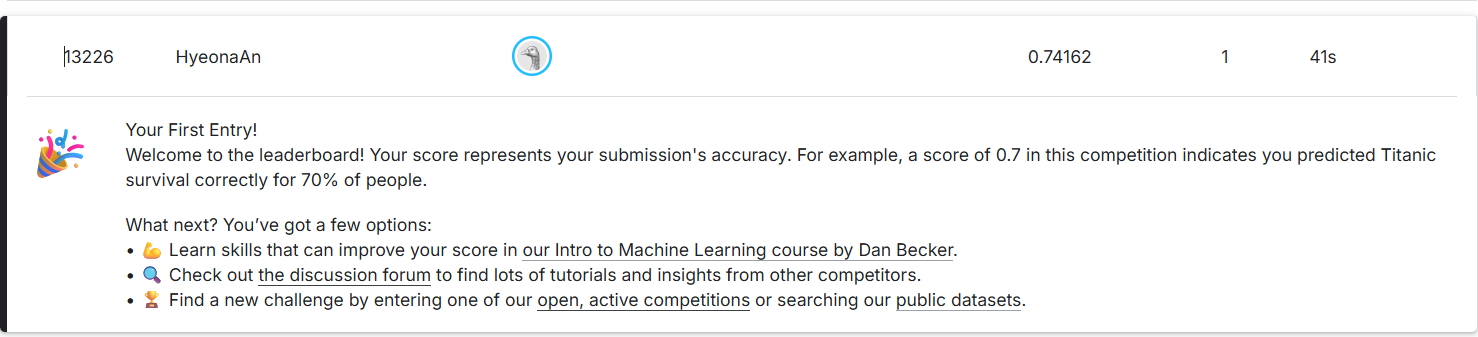

In [ ]:
#캐글 csv 파일 제출 자료 
from IPython.display import Image, display

display(Image(filename='Titanic.png', width=600))

# 원본 URL : https://drive.google.com/file/d/1as6S-oUbz6Zxdis1dsEiqtHeb30gJi1L/view


In [ ]:
''' [숙제 후기]
이번 과제를 통해 단순히 모델을 구성하는 것뿐 아니라,
하이퍼파라미터의 변화가 성능에 미치는 영향을 체계적으로 분석하는 과정의 중요성을 배웠다.
특히 Activation Function의 선택이 학습 속도뿐 아니라 최종 성능에도 큰 영향을 미친다는 점,
그리고 Batch Size가 너무 크면 일반화 능력이 떨어진다는 점을 실험적으로 확인할 수 있었다.

또한 Kaggle 플랫폼을 활용하여 실제 데이터 기반의 모델 성능 평가 및 제출 절차(submission.csv 생성) 를 직접 수행함으로써,
머신러닝 모델 개발의 전 과정을 실습할 수 있었다.

앞으로는 Dropout, Weight Decay, Learning Rate Scheduling 등 추가 요소를 실험하여
더 높은 일반화 성능을 목표로 개선할 예정이다.
'''